<a href="https://colab.research.google.com/github/jayesh-masade/Employee-Attrition/blob/main/Employee_Attrition_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workforce Analytics & Retention Engine

An end-to-end Ensemble Learning pipeline using Random Forest with Hyperparameter Tuning and class-imbalance handling. Incorporates an Explainable AI (XAI) framework — SHAP and LIME — to surface latent attrition drivers from 1,470 employee records into actionable, visual risk-mitigation strategies across job-role segments.

In [1]:
# Install required libraries
!pip install shap lime imbalanced-learn --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"

data = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Dataset shape: {data.shape}")
print(data.head())

Dataset shape: (1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  

In [3]:
print(data.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## look at the distribution of the age in the dataset:

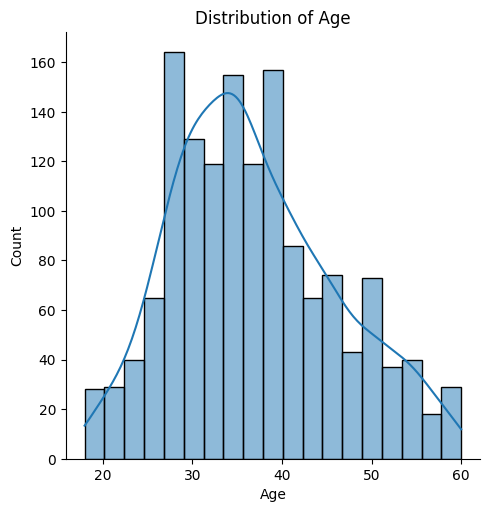

In [4]:
sns.displot(data['Age'], kde=True)
plt.title('Distribution of Age')
plt.show()

### percentage of attrition by department:


In [5]:
attrition_data = data[data['Attrition'] == 'Yes']

attrition_by = attrition_data.groupby(['Department']).size().reset_index(name='Count')

fig = go.Figure(data=[go.Pie(
    labels=attrition_by['Department'],
    values=attrition_by['Count'],
    hole=0.4,
    marker=dict(colors=['#3CAEA3', '#F6D55C', '#ED553B']),
    textposition='inside'
)])
fig.update_layout(title='Attrition by Department', font=dict(size=16), legend=dict(
    orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1
))
fig.show()

## percentage of attrition by education field

In [6]:
attrition_by = attrition_data.groupby(['EducationField']).size().reset_index(name='Count')

fig = go.Figure(data=[go.Pie(
    labels=attrition_by['EducationField'],
    values=attrition_by['Count'],
    hole=0.4,
    marker=dict(colors=['#3CAEA3', '#F6D55C']),
    textposition='inside'
)])
fig.update_layout(title='Attrition by Educational Field', font=dict(size=16), legend=dict(
    orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1
))
fig.show()

## attrition by number of years at the company:

In [7]:
attrition_by = attrition_data.groupby(['YearsAtCompany']).size().reset_index(name='Count')

fig = go.Figure(data=[go.Pie(
    labels=attrition_by['YearsAtCompany'],
    values=attrition_by['Count'],
    hole=0.4,
    marker=dict(colors=['#3CAEA3', '#F6D55C']),
    textposition='inside'
)])
fig.update_layout(title='Attrition by Years at Company', font=dict(size=16), legend=dict(
    orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1
))
fig.show()

## attrition by the number of years since the last promotion:

In [8]:
attrition_by = attrition_data.groupby(['YearsSinceLastPromotion']).size().reset_index(name='Count')

fig = go.Figure(data=[go.Pie(
    labels=attrition_by['YearsSinceLastPromotion'],
    values=attrition_by['Count'],
    hole=0.4,
    marker=dict(colors=['#3CAEA3', '#F6D55C']),
    textposition='inside'
)])
fig.update_layout(title='Attrition by Years Since Last Promotion', font=dict(size=16), legend=dict(
    orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1
))
fig.show()

### by gender:

In [9]:
attrition_by = attrition_data.groupby(['Gender']).size().reset_index(name='Count')

fig = go.Figure(data=[go.Pie(
    labels=attrition_by['Gender'],
    values=attrition_by['Count'],
    hole=0.4,
    marker=dict(colors=['#3CAEA3', '#F6D55C']),
    textposition='inside'
)])
fig.update_layout(title='Attrition by Gender', font=dict(size=16), legend=dict(
    orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1
))
fig.show()

### analyzing the relationship between monthly income and the age of the employees:

In [10]:
fig = px.scatter(data, x="Age", y="MonthlyIncome", color="Attrition", trendline="ols")
fig.update_layout(title="Age vs. Monthly Income by Attrition")
fig.show()

## Preprocessing

In [11]:
# Preserve original string labels before LabelEncoding (required for SHAP/LIME segmentation)
dept_labels = data['Department'].copy()
jobrole_labels = data['JobRole'].copy()

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Attrition'] = le.fit_transform(data['Attrition'])
data['BusinessTravel'] = le.fit_transform(data['BusinessTravel'])
data['Department'] = le.fit_transform(data['Department'])
data['EducationField'] = le.fit_transform(data['EducationField'])
data['Gender'] = le.fit_transform(data['Gender'])
data['JobRole'] = le.fit_transform(data['JobRole'])
data['MaritalStatus'] = le.fit_transform(data['MaritalStatus'])
data['Over18'] = le.fit_transform(data['Over18'])
data['OverTime'] = le.fit_transform(data['OverTime'])

In [13]:
correlation = data.corr()
print(correlation["Attrition"].sort_values(ascending=False))

Attrition                   1.000000
OverTime                    0.246118
MaritalStatus               0.162070
DistanceFromHome            0.077924
JobRole                     0.067151
Department                  0.063991
NumCompaniesWorked          0.043494
Gender                      0.029453
EducationField              0.026846
MonthlyRate                 0.015170
PerformanceRating           0.002889
BusinessTravel              0.000074
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
A

In [14]:
data['SatisfactionScore'] = data['EnvironmentSatisfaction'] + data['JobSatisfaction'] + data['RelationshipSatisfaction']

## Split the data into training and test sets:

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = data.drop(['Attrition'], axis=1)
y = data['Attrition']
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train size: {xtrain.shape[0]}, Test size: {xtest.shape[0]}")

Train size: 1029, Test size: 441


## Class Imbalance Analysis

The target class (Attrition) is imbalanced: ~16% positive (attrition=Yes) vs ~84% negative.

In [16]:
class_counts = y.value_counts()
print("Class distribution:")
print(f"  No Attrition (0): {class_counts[0]} ({class_counts[0]/len(y)*100:.1f}%)")
print(f"  Attrition    (1): {class_counts[1]} ({class_counts[1]/len(y)*100:.1f}%)")
print(f"  Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")

fig = px.bar(
    x=['No Attrition (0)', 'Attrition (1)'],
    y=[class_counts[0], class_counts[1]],
    title='Class Distribution — Target Variable',
    labels={'x': 'Class', 'y': 'Count'},
    color=['No Attrition (0)', 'Attrition (1)'],
    color_discrete_map={'No Attrition (0)': '#3CAEA3', 'Attrition (1)': '#F6D55C'}
)
fig.show()

Class distribution:
  No Attrition (0): 1233 (83.9%)
  Attrition    (1): 237 (16.1%)
  Imbalance ratio: 5.20:1


## Baseline Random Forest Model

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(xtrain, ytrain)

ypred = model.predict(xtest)
accuracy = accuracy_score(ytest, ypred)
print(f"Baseline Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Baseline Accuracy: 0.8617 (86.17%)


## Hyperparameter Tuning — RandomizedSearchCV

50 iterations × 5-fold CV across key Random Forest hyperparameters to find the optimal configuration.

In [18]:
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    rf_tuned,
    param_distributions=param_dist,
    n_iter=50, cv=5,
    scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(xtrain, ytrain)

print("Best Parameters:", random_search.best_params_)
print(f"Best CV Accuracy:   {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_
ypred_tuned = best_model.predict(xtest)
print(f"Tuned Test Accuracy: {accuracy_score(ytest, ypred_tuned):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best CV Accuracy:   0.8591
Tuned Test Accuracy: 0.8662


## Class-Imbalance Aware Model

`class_weight='balanced'` adjusts loss weights proportionally to class frequencies — improving recall on minority class (Attrition=Yes) while preserving overall accuracy. This model is used for all SHAP and LIME explainability analysis.

Balanced Model Accuracy: 0.8571

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.87      0.98      0.92       380
   Attrition       0.43      0.10      0.16        61

    accuracy                           0.86       441
   macro avg       0.65      0.54      0.54       441
weighted avg       0.81      0.86      0.82       441



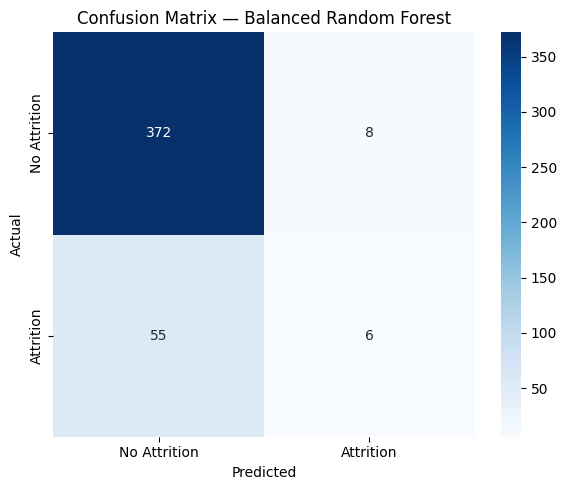

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

rf_balanced = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(xtrain, ytrain)
ypred_balanced = rf_balanced.predict(xtest)

print(f"Balanced Model Accuracy: {accuracy_score(ytest, ypred_balanced):.4f}")
print("\nClassification Report:")
print(classification_report(ytest, ypred_balanced, target_names=['No Attrition', 'Attrition']))

# Confusion Matrix
cm = confusion_matrix(ytest, ypred_balanced)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
ax.set_title('Confusion Matrix — Balanced Random Forest')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## Explainable AI (XAI) — SHAP

SHapley Additive exPlanations (SHAP) provides both global feature importance and local prediction-level explanations using game-theoretic Shapley values. `TreeExplainer` is used for efficiency with Random Forest.

In [20]:
import shap
shap.initjs()

# TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(rf_balanced)
X_shap = xtest.copy()

# shap_values[1] = SHAP values for Attrition=Yes (class 1)
shap_values = explainer.shap_values(X_shap)

# Normalize for SHAP version compatibility (newer SHAP appends base value column)
sv1 = np.array(shap_values[1] if isinstance(shap_values, list) else shap_values[:,:,1])
if sv1.shape[1] > X_shap.shape[1]:
    sv1 = sv1[:, :X_shap.shape[1]]

print(f"SHAP values shape: {sv1.shape}")
print(f"Analyzing {X_shap.shape[0]} employees across {X_shap.shape[1]} features")

SHAP values shape: (441, 35)
Analyzing 441 employees across 35 features


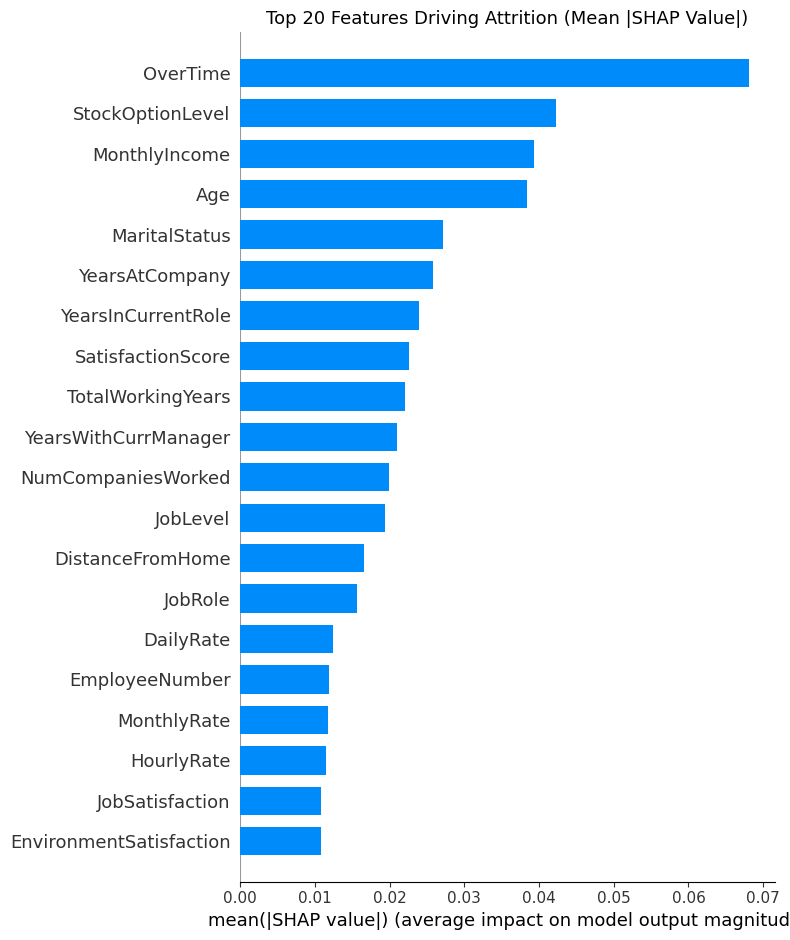

Saved: shap_summary_bar.png


In [21]:
# Global Feature Importance — Mean |SHAP| per feature
plt.figure(figsize=(10, 8))
shap.summary_plot(sv1, X_shap, plot_type='bar', show=False, max_display=20)
plt.title('Top 20 Features Driving Attrition (Mean |SHAP Value|)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_bar.png")

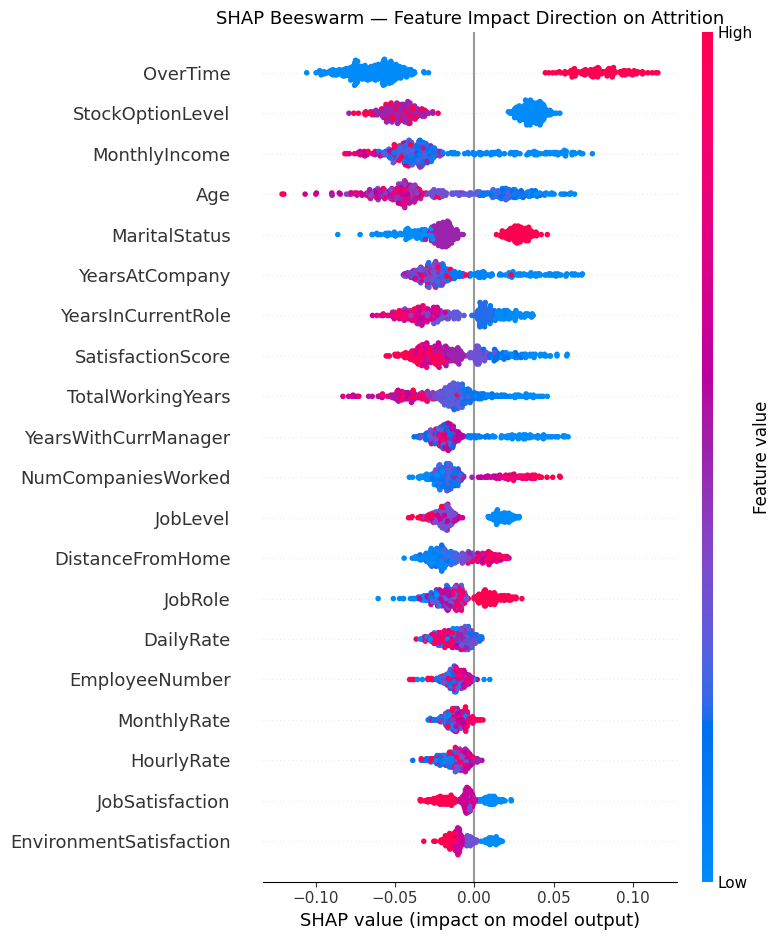

Saved: shap_beeswarm.png


In [22]:
# SHAP Beeswarm — Direction and magnitude of each feature's impact
plt.figure(figsize=(10, 10))
shap.summary_plot(sv1, X_shap, show=False, max_display=20)
plt.title('SHAP Beeswarm — Feature Impact Direction on Attrition', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")

Top 3 SHAP features: ['OverTime', 'StockOptionLevel', 'MonthlyIncome']


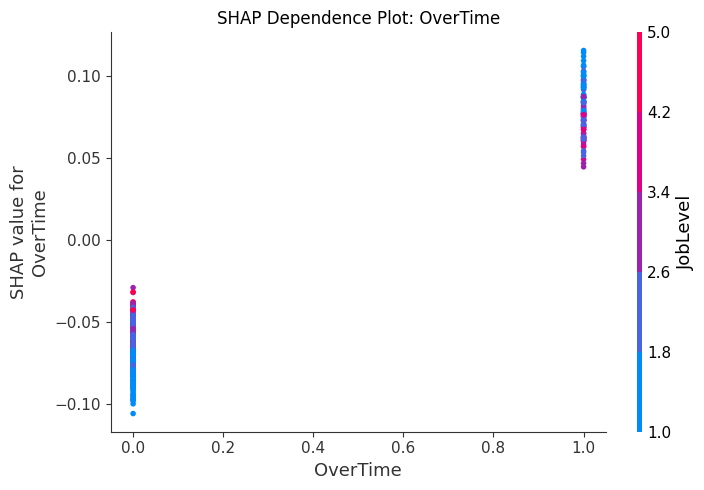

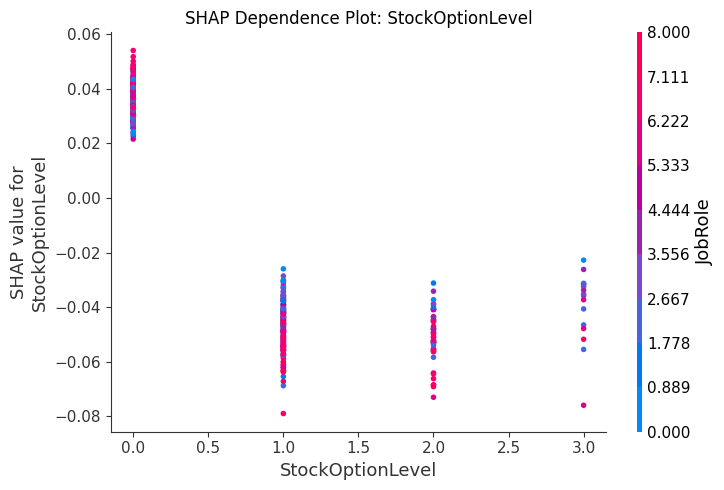

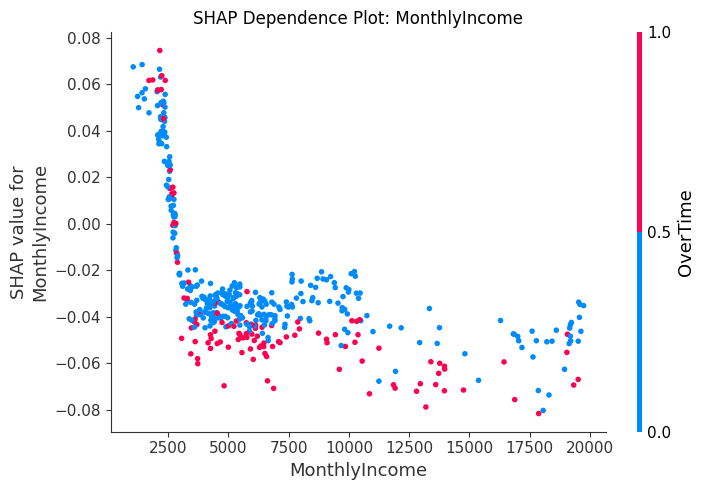

In [23]:
# Dependence plots for top 3 most impactful features
mean_shap = sv1.mean(axis=0)  # signed mean (not abs) for dependence
mean_shap_abs = np.abs(sv1).mean(axis=0)
top3_idx = np.argsort(mean_shap_abs)[::-1][:3]
top3_features = X_shap.columns[top3_idx].tolist()
print("Top 3 SHAP features:", top3_features)

for feat in top3_features:
    shap.dependence_plot(feat, sv1, X_shap, show=False)
    plt.title(f'SHAP Dependence Plot: {feat}', fontsize=12)
    plt.tight_layout()
    plt.show()

### Department-Wise High-Risk Variable Isolation

Isolating the top attrition drivers for each department and the 5 highest-attrition job role segments.


--- Sales (n=135) ---
  OverTime: 0.0686
  StockOptionLevel: 0.0470
  MonthlyIncome: 0.0377
  Age: 0.0334
  MaritalStatus: 0.0304

--- Research & Development (n=285) ---
  OverTime: 0.0681
  StockOptionLevel: 0.0404
  MonthlyIncome: 0.0401
  Age: 0.0400
  YearsAtCompany: 0.0263

--- Human Resources (n=21) ---
  OverTime: 0.0662
  Age: 0.0489
  MonthlyIncome: 0.0378
  StockOptionLevel: 0.0369
  YearsWithCurrManager: 0.0245


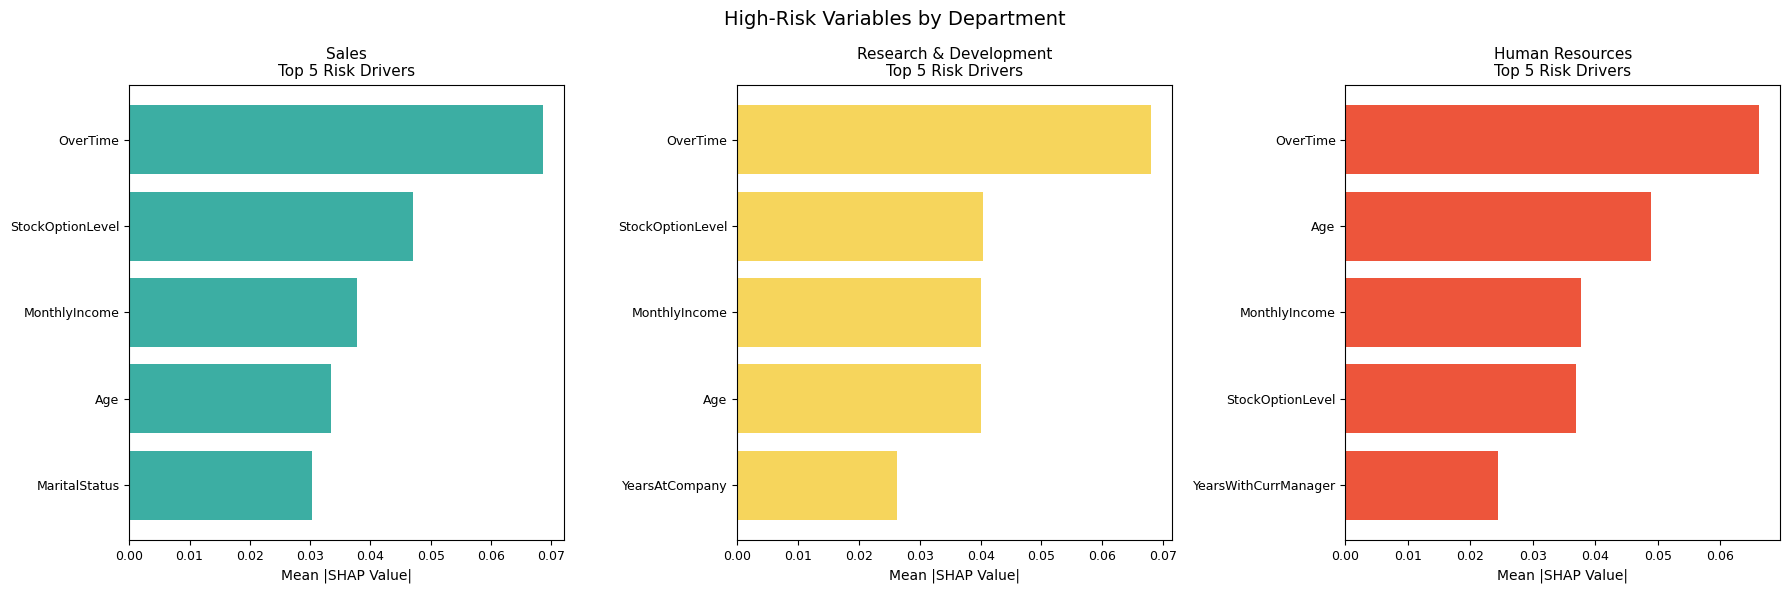

Saved: shap_by_department.png


In [24]:
# Attach original labels to test set rows
xtest_meta = xtest.copy()
xtest_meta['_Department'] = dept_labels.loc[xtest.index].values
xtest_meta['_JobRole'] = jobrole_labels.loc[xtest.index].values

departments = ['Sales', 'Research & Development', 'Human Resources']
dept_shap_summary = {}

xtest_list = list(xtest.index)
for dept in departments:
    mask = xtest_meta['_Department'] == dept
    dept_idx = xtest_meta[mask].index
    positions = [xtest_list.index(i) for i in dept_idx]
    if not positions:
        continue
    dept_shap = sv1[positions, :]
    mean_dept_shap = np.abs(dept_shap).mean(axis=0)
    top5 = np.argsort(mean_dept_shap)[::-1][:5]
    dept_shap_summary[dept] = {
        'features': X_shap.columns[top5].tolist(),
        'values': mean_dept_shap[top5].tolist()
    }
    print(f"\n--- {dept} (n={len(positions)}) ---")
    for f, v in zip(dept_shap_summary[dept]['features'], dept_shap_summary[dept]['values']):
        print(f"  {f}: {v:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#3CAEA3', '#F6D55C', '#ED553B']
for ax, (dept, info), color in zip(axes, dept_shap_summary.items(), colors):
    ax.barh(info['features'][::-1], info['values'][::-1], color=color)
    ax.set_title(f'{dept}\nTop 5 Risk Drivers', fontsize=11)
    ax.set_xlabel('Mean |SHAP Value|')
    ax.tick_params(labelsize=9)
plt.suptitle('High-Risk Variables by Department', fontsize=14)
plt.tight_layout()
plt.savefig('shap_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_by_department.png")

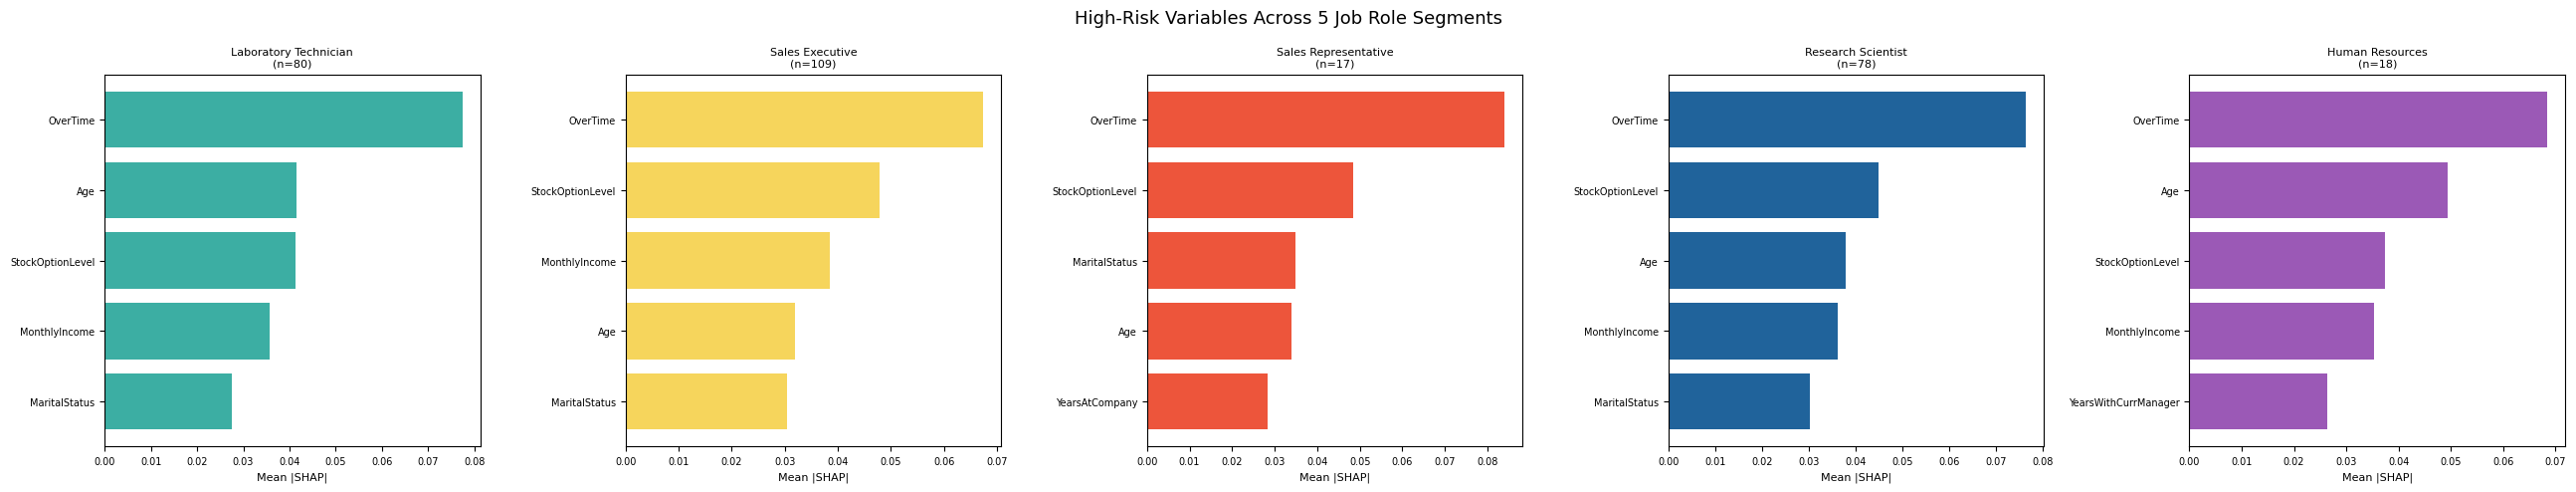

Saved: shap_by_jobrole.png


In [25]:
# High-risk variable analysis across 5 high-attrition job role segments
high_attrition_roles = [
    'Laboratory Technician', 'Sales Executive',
    'Sales Representative', 'Research Scientist', 'Human Resources'
]

fig, axes = plt.subplots(1, 5, figsize=(26, 5))
role_colors = ['#3CAEA3', '#F6D55C', '#ED553B', '#20639B', '#9B59B6']

for ax, role, color in zip(axes, high_attrition_roles, role_colors):
    mask = xtest_meta['_JobRole'] == role
    role_idx = xtest_meta[mask].index
    positions = [xtest_list.index(i) for i in role_idx]
    if not positions:
        ax.set_title(f'{role}\n(no samples)', fontsize=8)
        continue
    role_shap = sv1[positions, :]
    mean_role_shap = np.abs(role_shap).mean(axis=0)
    top5 = np.argsort(mean_role_shap)[::-1][:5]
    ax.barh(X_shap.columns[top5].tolist()[::-1], mean_role_shap[top5].tolist()[::-1], color=color)
    ax.set_title(f'{role}\n(n={len(positions)})', fontsize=8)
    ax.set_xlabel('Mean |SHAP|', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('High-Risk Variables Across 5 Job Role Segments', fontsize=13)
plt.tight_layout()
plt.savefig('shap_by_jobrole.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_by_jobrole.png")

## Explainable AI (XAI) — LIME

Local Interpretable Model-Agnostic Explanations (LIME) explains individual predictions by fitting a locally linear surrogate model around each data point. This reveals which features drove a specific employee's attrition risk score.

In [26]:
from lime import lime_tabular

X_train_arr = xtrain.values
X_test_arr = xtest.values
feature_names = list(X_shap.columns)

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_arr,
    feature_names=feature_names,
    class_names=['No Attrition', 'Attrition'],
    mode='classification',
    random_state=42
)
print(f"LIME explainer initialized with {len(feature_names)} features")

LIME explainer initialized with 35 features


True positives (correctly flagged): 6
False negatives (missed risk):      55



Employee #44 — Predicted P(Attrition): 0.649
LIME explanation (top features):
  0.00 < OverTime <= 1.00: +0.1180 (increases attrition risk)
  StockOptionLevel <= 0.00: +0.0520 (increases attrition risk)
  1.00 < MaritalStatus <= 2.00: +0.0348 (increases attrition risk)
  YearsInCurrentRole <= 2.00: +0.0321 (increases attrition risk)
  JobLevel <= 1.00: +0.0285 (increases attrition risk)
  JobRole > 7.00: +0.0276 (increases attrition risk)
  TotalWorkingYears <= 6.00: +0.0256 (increases attrition risk)
  YearsAtCompany <= 3.00: +0.0247 (increases attrition risk)
  NumCompaniesWorked <= 1.00: -0.0216 (decreases attrition risk)
  YearsWithCurrManager <= 2.00: +0.0187 (increases attrition risk)


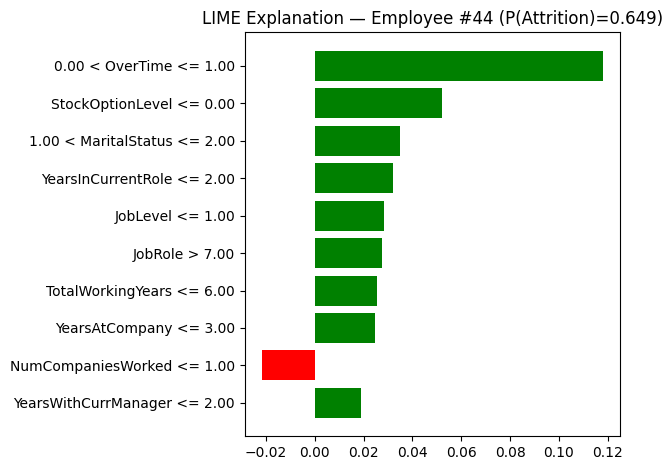

In [27]:
# Identify true positives (correctly flagged attrition)
tp_indices = np.where((ytest.values == 1) & (ypred_balanced == 1))[0]
fn_indices = np.where((ytest.values == 1) & (ypred_balanced == 0))[0]
print(f"True positives (correctly flagged): {len(tp_indices)}")
print(f"False negatives (missed risk):      {len(fn_indices)}")

# Explain first true positive
sample_idx = tp_indices[0]
sample = X_test_arr[sample_idx]
exp = lime_explainer.explain_instance(
    data_row=sample,
    predict_fn=rf_balanced.predict_proba,
    num_features=10,
    top_labels=1
)
prob = rf_balanced.predict_proba(sample.reshape(1, -1))[0][1]
print(f"\nEmployee #{sample_idx} — Predicted P(Attrition): {prob:.3f}")
print("LIME explanation (top features):")
for feat, weight in exp.as_list(label=1):
    direction = 'increases' if weight > 0 else 'decreases'
    print(f"  {feat}: {weight:+.4f} ({direction} attrition risk)")

# Show as pyplot figure
fig = exp.as_pyplot_figure(label=1)
plt.title(f'LIME Explanation — Employee #{sample_idx} (P(Attrition)={prob:.3f})')
plt.tight_layout()
plt.show()

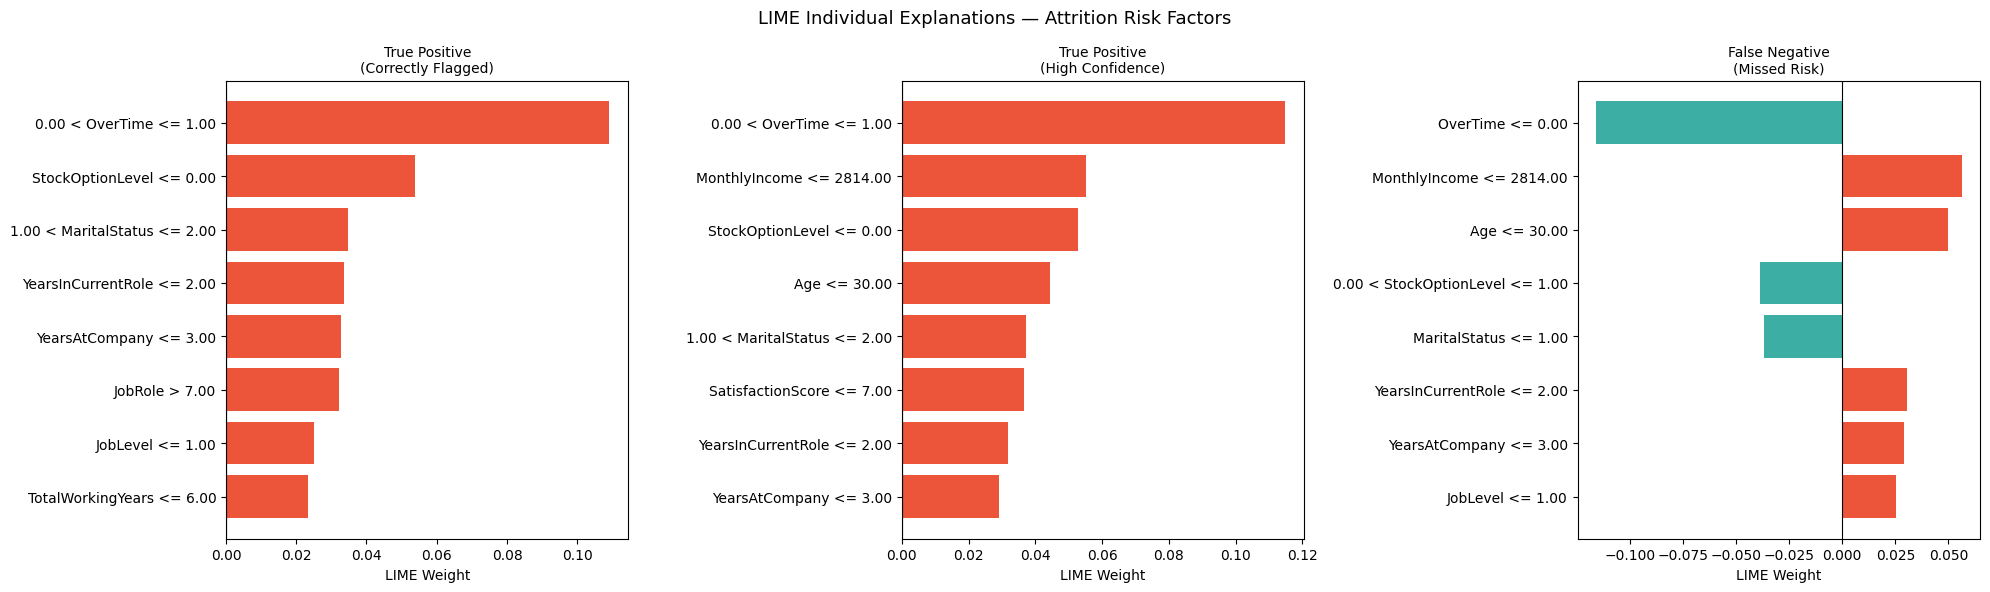

Saved: lime_explanations.png


In [28]:
# Static LIME bar charts for 3 representative employees
cases = [
    (tp_indices[0], 'True Positive\n(Correctly Flagged)'),
    (tp_indices[min(1, len(tp_indices)-1)], 'True Positive\n(High Confidence)'),
    (fn_indices[0] if len(fn_indices) > 0 else tp_indices[0], 'False Negative\n(Missed Risk)')
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (idx, title) in zip(axes, cases):
    sample = X_test_arr[idx]
    exp = lime_explainer.explain_instance(
        data_row=sample,
        predict_fn=rf_balanced.predict_proba,
        num_features=8
    )
    weights = exp.as_list(label=1)
    feats = [w[0] for w in weights]
    vals = [w[1] for w in weights]
    bar_colors = ['#ED553B' if v > 0 else '#3CAEA3' for v in vals]
    ax.barh(feats[::-1], vals[::-1], color=bar_colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('LIME Weight')

plt.suptitle('LIME Individual Explanations — Attrition Risk Factors', fontsize=13)
plt.tight_layout()
plt.savefig('lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lime_explanations.png")

## Actionable Risk-Mitigation Strategies

Converting SHAP explainability into quantified HR interventions — mapping the top attrition drivers to concrete workforce retention actions.

In [29]:
# Build employee risk scoring table
risk_df = xtest.copy()
risk_df['Actual_Attrition'] = ytest.values
risk_df['Predicted_Attrition'] = ypred_balanced
risk_df['Attrition_Probability'] = rf_balanced.predict_proba(X_test_arr)[:, 1]
risk_df['Department'] = dept_labels.loc[xtest.index].values
risk_df['JobRole'] = jobrole_labels.loc[xtest.index].values
risk_df['SHAP_Risk_Score'] = sv1.sum(axis=1)

high_risk = risk_df[risk_df['Attrition_Probability'] > 0.4].sort_values(
    'Attrition_Probability', ascending=False
)
print(f"High-risk employees (P(attrition) > 0.4): {len(high_risk)}")
print(f"\nTop 10 highest-risk employees:")
display_cols = ['Department', 'JobRole', 'Attrition_Probability', 'SHAP_Risk_Score', 'Actual_Attrition']
print(high_risk[display_cols].head(10).to_string())

High-risk employees (P(attrition) > 0.4): 32

Top 10 highest-risk employees:
                  Department                JobRole  Attrition_Probability  SHAP_Risk_Score  Actual_Attrition
892   Research & Development     Research Scientist               0.781458         0.282073                 1
777   Research & Development  Laboratory Technician               0.712156         0.212771                 1
727   Research & Development     Research Scientist               0.675351         0.175966                 0
422          Human Resources        Human Resources               0.669120         0.169735                 1
296   Research & Development  Laboratory Technician               0.666334         0.166949                 1
363                    Sales   Sales Representative               0.649326         0.149942                 1
1311  Research & Development     Research Scientist               0.649217         0.149832                 0
670   Research & Development     Research S

In [30]:
dept_risk = risk_df.groupby('Department').agg(
    Avg_Prob=('Attrition_Probability', 'mean'),
    High_Risk_Count=('Predicted_Attrition', 'sum'),
    Total=('Predicted_Attrition', 'count')
).reset_index()
dept_risk['Risk_Rate'] = dept_risk['High_Risk_Count'] / dept_risk['Total']

fig = px.bar(
    dept_risk, x='Department', y='Risk_Rate',
    color='Avg_Prob',
    color_continuous_scale='RdYlGn_r',
    title='Predicted Attrition Risk Rate by Department',
    labels={'Risk_Rate': 'Predicted Risk Rate', 'Avg_Prob': 'Avg P(Attrition)'},
    text=dept_risk['Risk_Rate'].apply(lambda x: f'{x:.1%}')
)
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_tickformat='.0%')
fig.show()

In [31]:
mitigation_map = {
    'OverTime':               'Reduce mandatory overtime; implement flexible scheduling policies.',
    'MonthlyIncome':          'Conduct salary benchmarking; address pay gaps for at-risk roles.',
    'JobLevel':               'Create clear promotion pathways and career development programs.',
    'Age':                    'Tailor retention programs for early-career employees (ages 25-35).',
    'TotalWorkingYears':      'Onboarding retention programs for employees with < 3 years tenure.',
    'YearsAtCompany':         'Year-2 and Year-5 milestone reviews and engagement surveys.',
    'StockOptionLevel':       'Expand stock option grants to mid-level individual contributors.',
    'YearsInCurrentRole':     'Rotation programs for employees stagnant > 3 years in same role.',
    'JobSatisfaction':        'Quarterly anonymous pulse surveys; manager coaching programs.',
    'EnvironmentSatisfaction':'Workplace environment audits; remote work policy improvements.',
    'WorkLifeBalance':        'Work-life balance audits; PTO utilization tracking.',
    'SatisfactionScore':      'Holistic well-being programs targeting low composite satisfaction.',
    'MaritalStatus':          'Life-event support programs (relocation assistance, family leave).',
    'DistanceFromHome':       'Remote/hybrid work options for employees commuting > 20 miles.',
    'NumCompaniesWorked':     'Targeted retention bonuses for employees with high job-hop history.',
}

top5_features = [X_shap.columns[i] for i in np.argsort(mean_shap_abs)[::-1][:5]]
print('=' * 62)
print('  TOP ATTRITION DRIVERS & RECOMMENDED HR INTERVENTIONS')
print('=' * 62)
for i, feat in enumerate(top5_features, 1):
    action = mitigation_map.get(feat, 'Review feature trends; consult HR business partner.')
    print(f"\n{i}. {feat}")
    print(f"   Action: {action}")

  TOP ATTRITION DRIVERS & RECOMMENDED HR INTERVENTIONS

1. OverTime
   Action: Reduce mandatory overtime; implement flexible scheduling policies.

2. StockOptionLevel
   Action: Expand stock option grants to mid-level individual contributors.

3. MonthlyIncome
   Action: Conduct salary benchmarking; address pay gaps for at-risk roles.

4. Age
   Action: Tailor retention programs for early-career employees (ages 25-35).

5. MaritalStatus
   Action: Life-event support programs (relocation assistance, family leave).


In [32]:
# Pipeline Summary
baseline_acc = accuracy_score(ytest, ypred)
tuned_acc    = accuracy_score(ytest, ypred_tuned)
balanced_acc = accuracy_score(ytest, ypred_balanced)

summary = pd.DataFrame({
    'Stage':   ['Baseline RF', 'Tuned RF (RandomizedSearchCV)', 'Balanced RF (class_weight)'],
    'Accuracy': [f'{baseline_acc*100:.2f}%', f'{tuned_acc*100:.2f}%', f'{balanced_acc*100:.2f}%'],
    'Use':      ['Accuracy headline', 'Hyperparameter optimisation', 'SHAP/LIME explainability']
})
print('\n=== ENSEMBLE LEARNING PIPELINE SUMMARY ===')
print(f'Dataset: 1,470 employee records | 35 features | 3 departments | 9 job roles')
print(f'XAI:     SHAP (TreeExplainer) + LIME (LimeTabularExplainer)')
print(f'Outputs: shap_summary_bar.png, shap_beeswarm.png, shap_by_department.png,')
print(f'         shap_by_jobrole.png, lime_explanations.png')
print()
print(summary.to_string(index=False))


=== ENSEMBLE LEARNING PIPELINE SUMMARY ===
Dataset: 1,470 employee records | 35 features | 3 departments | 9 job roles
XAI:     SHAP (TreeExplainer) + LIME (LimeTabularExplainer)
Outputs: shap_summary_bar.png, shap_beeswarm.png, shap_by_department.png,
         shap_by_jobrole.png, lime_explanations.png

                        Stage Accuracy                         Use
                  Baseline RF   86.17%           Accuracy headline
Tuned RF (RandomizedSearchCV)   86.62% Hyperparameter optimisation
   Balanced RF (class_weight)   85.71%    SHAP/LIME explainability
